# Neutrality Test — Streamlit App

Interactive Streamlit app for the `neutrality_lrt` function from `neutrality_test.py`.

**Input format:** CSV files where **columns = samples/recipients** and **rows = features** (taxa / genes / sgRNAs).

**Outputs:** results table, a log2-fold-change scatter plot, a full results CSV, and a CSV of the `down_in_recipient` features.

**Requirements**
```
pip install streamlit numpy pandas scipy statsmodels matplotlib
```

Run all cells in order. The last cell starts the Streamlit server.

> All file writes/reads use `encoding='utf-8'` so the notebook runs cleanly on Windows.

## 1 · Install dependencies (run once)

In [1]:
%pip install streamlit numpy pandas scipy statsmodels matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2 · Write `neutrality_test.py` to disk

In [2]:
neutrality_test_source = '''
"""
Neutrality test for donor->recipient transmission experiments.
"""
from __future__ import annotations
from dataclasses import dataclass
from typing import Iterable, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.special import gammaln
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

_MIN_PVAL = float(np.nextafter(0.0, 1.0))

def _log_beta(a, b):
    return float(gammaln(a) + gammaln(b) - gammaln(a + b))

def _log_bb_pmf(x, n, a, b):
    return float(
        (gammaln(n + 1) - gammaln(x + 1) - gammaln(n - x + 1))
        + _log_beta(x + a, n - x + b)
        - _log_beta(a, b)
    )

def _loglik_feature(q, x_vec, n_vec, Nb_vec, *, alpha0, q_bounds):
    lo, hi = q_bounds
    q = float(np.clip(q, lo, hi))
    ll = 0.0
    for xm, nm, Nbm in zip(x_vec, n_vec, Nb_vec):
        if nm <= 0:
            continue
        a = float(Nbm * q + alpha0)
        b = float(Nbm * (1.0 - q) + alpha0)
        ll += _log_bb_pmf(int(xm), int(nm), a, b)
    return float(ll)

def _fit_q_mle(x_vec, n_vec, Nb_vec, *, alpha0, q_bounds):
    lo, hi = q_bounds
    def nll(q):
        return -_loglik_feature(q, x_vec, n_vec, Nb_vec, alpha0=alpha0, q_bounds=q_bounds)
    res = minimize_scalar(nll, bounds=(lo, hi), method="bounded")
    return float(res.x), float(-res.fun)

def _as_1d_float_array(x, length):
    if np.isscalar(x):
        return np.full(length, float(x), dtype=float)
    arr = np.asarray(x, dtype=float).reshape(-1)
    if arr.shape[0] != length:
        raise ValueError(f"bottleneck has length {arr.shape[0]}, expected {length}")
    return arr

def neutrality_lrt(
    donor_counts, recipient_counts, bottleneck, *,
    feature_ids=None, pseudocount=1e-6, alpha0=1e-12,
    min_p=1e-8, q_bounds=(1e-12, 1 - 1e-12),
    fdr_alpha=0.05, fdr_method="fdr_bh",
):
    if isinstance(recipient_counts, pd.DataFrame):
        X = recipient_counts.to_numpy(dtype=np.int64)
        cols_from_recip = list(recipient_counts.columns)
    else:
        X = np.asarray(recipient_counts, dtype=np.int64)
        cols_from_recip = None
    if X.ndim == 1:
        X = X.reshape(1, -1)
    if X.ndim != 2:
        raise ValueError("recipient_counts must be 1D or 2D")
    M, K = X.shape

    if isinstance(donor_counts, pd.Series):
        donor_arr = donor_counts.to_numpy(dtype=float).reshape(-1)
        ids_from_donor = list(donor_counts.index)
    else:
        donor_arr = np.asarray(donor_counts, dtype=float).reshape(-1)
        ids_from_donor = None
    if donor_arr.shape[0] != K:
        raise ValueError(f"donor_counts length does not match K={K}")

    if feature_ids is None:
        if cols_from_recip is not None:
            feature_ids = cols_from_recip
        elif ids_from_donor is not None:
            feature_ids = ids_from_donor
        else:
            feature_ids = list(range(K))

    Nb_vec = _as_1d_float_array(bottleneck, M)
    n_tot  = X.sum(axis=1).astype(np.int64)
    donor_adj = donor_arr + float(pseudocount)
    p_donor   = donor_adj / donor_adj.sum()

    q_hat = np.full(K, np.nan)
    LR    = np.full(K, np.nan)
    pval  = np.full(K, np.nan)

    for j in range(K):
        p0 = float(p_donor[j])
        if (not np.isfinite(p0)) or (p0 < min_p) or (p0 > 1.0 - min_p):
            continue
        x_vec = X[:, j].astype(np.int64, copy=False)
        ll0 = _loglik_feature(p0, x_vec, n_tot, Nb_vec, alpha0=alpha0, q_bounds=q_bounds)
        qh, ll1 = _fit_q_mle(x_vec, n_tot, Nb_vec, alpha0=alpha0, q_bounds=q_bounds)
        q_hat[j] = qh
        LRj = max(0.0, 2.0 * (ll1 - ll0))
        LR[j] = LRj
        p = float(chi2.sf(LRj, df=1))
        if (not np.isfinite(p)) or p <= 0.0:
            p = _MIN_PVAL
        pval[j] = p

    tested = np.isfinite(pval)
    qval   = np.full(K, np.nan)
    reject = np.zeros(K, dtype=bool)
    if tested.any():
        r, qv, _, _ = multipletests(pval[tested], alpha=float(fdr_alpha), method=str(fdr_method))
        qval[tested]  = np.maximum(qv, _MIN_PVAL)
        pval[tested]  = np.maximum(pval[tested], _MIN_PVAL)
        reject[tested] = r

    res = pd.DataFrame({
        "feature": list(feature_ids),
        "p_donor": p_donor,
        "q_hat_recipient_center": q_hat,
        "LR": LR,
        "pval": pval,
        "qval_FDR": qval,
        "reject_FDR": reject,
    })
    direction = pd.Series([None]*len(res), dtype="object")
    mask = np.isfinite(res["q_hat_recipient_center"].to_numpy(dtype=float))
    direction.loc[mask] = np.where(
        res.loc[mask, "q_hat_recipient_center"] > res.loc[mask, "p_donor"],
        "up_in_recipient", "down_in_recipient",
    )
    res["direction"] = direction
    return res.sort_values(["pval","LR"], ascending=[True,False]).reset_index(drop=True)
'''

with open('neutrality_test.py', 'w', encoding='utf-8') as f:
    f.write(neutrality_test_source)

print('neutrality_test.py written.')

neutrality_test.py written.


## 3 · Write the Streamlit app to `app_neutrality.py`

Input format: **columns = samples/recipients, rows = features**. Uploaded CSVs are transposed on read.
Visualisation: a single log2-fold-change scatter. Downloads: full results + `down_in_recipient` subset.

In [3]:
app_source = '''
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
from neutrality_test import neutrality_lrt

# -- Page config --------------------------------------------------------------
st.set_page_config(page_title="Neutrality LRT", layout="wide")
st.title("Neutrality Test - Donor to Recipient Transmission")
st.markdown(
    """
    Test whether each feature (taxon / gene / sgRNA) is **neutral** during transmission:
    - **H0**: recipient center frequency = donor frequency
    - **H1**: recipient center frequency is free
    Uses a likelihood-ratio test (LRT) with Dirichlet-Multinomial marginals
    and Benjamini-Hochberg FDR correction.
    """
)

# -- Sidebar - parameters -----------------------------------------------------
with st.sidebar:
    st.header("Parameters")
    bottleneck_input = st.text_input(
        "Bottleneck size Nb (scalar or comma-separated per recipient)",
        value="100",
        help="A single number (same Nb for all recipients) or one value per recipient sample."
    )
    fdr_alpha   = st.slider("FDR alpha", 0.01, 0.20, 0.05, 0.01)
    pseudocount = st.number_input("Donor pseudocount", value=1e-6, format="%.2e")
    min_p       = st.number_input("min_p (skip near-zero donor freqs)", value=1e-8, format="%.2e")
    fdr_method  = st.selectbox("FDR method", ["fdr_bh", "fdr_by", "holm", "bonferroni"])
    st.markdown("---")
    st.markdown("**Input format** - CSV files, columns = samples/recipients, rows = features (taxa / genes / sgRNAs).")

# -- Data input tabs ----------------------------------------------------------
tab_upload, tab_demo = st.tabs(["Upload your data", "Run demo"])

def parse_bottleneck(text, M):
    parts = [p.strip() for p in text.split(",") if p.strip()]
    if len(parts) == 1:
        return float(parts[0])
    arr = np.array([float(p) for p in parts])
    if len(arr) != M:
        st.error(f"Bottleneck has {len(arr)} values but there are {M} recipients.")
        st.stop()
    return arr

donor_df     = None
recipient_df = None

with tab_upload:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Donor / inoculum counts")
        st.caption("One column of raw counts; one row per feature.")
        donor_file = st.file_uploader("Upload donor CSV", type="csv", key="donor")
        if donor_file:
            donor_raw = pd.read_csv(donor_file, index_col=0)   # rows = features
            st.dataframe(donor_raw.head(), use_container_width=True)
            donor_df = donor_raw.T                             # -> 1 row (sample), cols = features
    with col2:
        st.subheader("Recipient counts")
        st.caption("Columns = recipients, rows = features (same feature order as donor).")
        recip_file = st.file_uploader("Upload recipient CSV", type="csv", key="recip")
        if recip_file:
            recip_raw = pd.read_csv(recip_file, index_col=0)   # rows = features, cols = recipients
            st.dataframe(recip_raw.head(), use_container_width=True)
            recipient_df = recip_raw.T                         # -> rows = recipients, cols = features

with tab_demo:
    st.markdown(
        """
        Generates **synthetic** data: 8 features, 6 recipients.
        Features A and B are shifted in recipients to simulate non-neutrality.
        Shown in the documented layout (rows = features, columns = samples).
        """
    )
    if st.button("Generate demo data"):
        rng = np.random.default_rng(42)
        K, M = 8, 6
        features = [f"Feature_{chr(65+i)}" for i in range(K)]
        donor_counts_demo = rng.integers(50, 500, size=K).astype(float)
        donor_df = pd.DataFrame([donor_counts_demo], columns=features, index=["donor"])
        p = donor_counts_demo / donor_counts_demo.sum()
        p_recip = p.copy()
        p_recip[0] *= 3; p_recip[1] *= 0.2
        p_recip /= p_recip.sum()
        rows = []
        for _ in range(M):
            n = rng.integers(800, 1200)
            rows.append(rng.multinomial(n, p_recip))
        recipient_df = pd.DataFrame(rows, columns=features,
                                    index=[f"recipient_{i+1}" for i in range(M)])
        st.session_state["donor_df"]     = donor_df
        st.session_state["recipient_df"] = recipient_df
        st.success("Demo data generated!")
        col1, col2 = st.columns(2)
        with col1:
            st.write("**Donor** (rows = features)"); st.dataframe(donor_df.T, use_container_width=True)
        with col2:
            st.write("**Recipients** (rows = features)"); st.dataframe(recipient_df.T, use_container_width=True)

# pull demo data into local vars if present (stored as recipients-as-rows for the model)
if donor_df is None and "donor_df" in st.session_state:
    donor_df     = st.session_state["donor_df"]
if recipient_df is None and "recipient_df" in st.session_state:
    recipient_df = st.session_state["recipient_df"]

# -- Run test -----------------------------------------------------------------
if donor_df is not None and recipient_df is not None:
    st.markdown("---")
    if st.button("Run neutrality LRT", type="primary"):
        with st.spinner("Running LRT ..."):
            if donor_df.shape[0] == 1:
                donor_series = donor_df.iloc[0]
            elif donor_df.shape[1] == 1:
                donor_series = donor_df.iloc[:, 0]
            else:
                donor_series = donor_df.iloc[0]
                st.warning("Donor has multiple samples; using the first.")

            M = recipient_df.shape[0]
            Nb = parse_bottleneck(bottleneck_input, M)

            results = neutrality_lrt(
                donor_counts=donor_series,
                recipient_counts=recipient_df,
                bottleneck=Nb,
                pseudocount=pseudocount,
                min_p=min_p,
                fdr_alpha=fdr_alpha,
                fdr_method=fdr_method,
            )
            st.session_state["results"] = results

    if "results" in st.session_state:
        results = st.session_state["results"]

        n_tested   = results["pval"].notna().sum()
        n_rejected = results["reject_FDR"].sum()
        n_down     = int((results["direction"] == "down_in_recipient").sum())
        m1, m2, m3, m4 = st.columns(4)
        m1.metric("Features tested", int(n_tested))
        m2.metric(f"Rejected (FDR {int(fdr_alpha*100)}%)", int(n_rejected))
        m3.metric("Not rejected (neutral)", int(n_tested - n_rejected))
        m4.metric("down_in_recipient", n_down)

        st.subheader("Results table")
        display_cols = ["feature","p_donor","q_hat_recipient_center",
                        "LR","pval","qval_FDR","reject_FDR","direction"]
        styled = results[display_cols].style.format(
            {"p_donor":"{:.4e}","q_hat_recipient_center":"{:.4e}",
             "LR":"{:.3f}","pval":"{:.2e}","qval_FDR":"{:.2e}"}
        ).apply(
            lambda col: ["background-color: #ffd6d6" if v else "" for v in col],
            subset=["reject_FDR"]
        )
        st.dataframe(styled, use_container_width=True)

        # -- Downloads: full results + down_in_recipient subset ---------------
        down_df = results[(results["direction"] == "down_in_recipient") & (results["reject_FDR"])].copy()
        dcol1, dcol2 = st.columns(2)
        with dcol1:
            st.download_button(
                "Download full results CSV",
                results.to_csv(index=False).encode(),
                "neutrality_results.csv", "text/csv"
            )
        with dcol2:
            st.download_button(
                f"Download down_in_recipient ({len(down_df)}) CSV",
                down_df.to_csv(index=False).encode(),
                "down_in_recipient.csv", "text/csv"
            )
        st.caption("The down_in_recipient file lists only the SIGNIFICANT depletions "
                   "(reject_FDR = True and recipient frequency below donor frequency), "
                   "ordered by significance.")

        # -- Single scatter: log2 fold-change vs -log10(p) --------------------
        st.subheader("log2 fold-change vs significance")
        eps = 1e-12
        plot_df = results.dropna(subset=["pval","q_hat_recipient_center","p_donor"]).copy()
        plot_df["log2_fc"]    = np.log2((plot_df["q_hat_recipient_center"] + eps) / (plot_df["p_donor"] + eps))
        plot_df["neglog10_p"] = -np.log10(plot_df["pval"])

        # Horizontal guide = FDR significance boundary on the raw-p scale
        rej = plot_df[plot_df["reject_FDR"]]
        if len(rej):
            hline = -np.log10(rej["pval"].max())
        else:
            hline = -np.log10(fdr_alpha)

        fig, ax = plt.subplots(figsize=(6.4, 5))
        blue = plot_df[~plot_df["reject_FDR"]]
        red  = plot_df[plot_df["reject_FDR"]]
        ax.scatter(blue["log2_fc"], blue["neglog10_p"], s=14, c="#3b7fbf", alpha=0.75, edgecolors="none")
        ax.scatter(red["log2_fc"],  red["neglog10_p"],  s=34, c="#e8261f", alpha=0.95, edgecolors="none")
        ax.axvline(0.0,   ls="--", lw=1, color="#6b7a99")
        ax.axhline(hline, ls="--", lw=1, color="#6b7a99")
        ax.set_xlabel(r"$log_2(\\hat{q}_j / D_j)$", fontsize=12)
        ax.set_ylabel(r"$-log_{10}(p_{FDR})$", fontsize=12)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=False)
        st.caption(f"Red = rejected at FDR {fdr_alpha}. Vertical dashed line: no change "
                   f"(recipient freq = donor freq). Horizontal dashed line: FDR significance boundary. "
                   f"Left of centre = depleted in recipients (down_in_recipient).")

        # optional PNG download of the figure
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=200, bbox_inches="tight")
        st.download_button("Download scatter (PNG)", buf.getvalue(),
                           "nonneutral_scatter.png", "image/png")
else:
    st.info("Upload donor + recipient CSVs, or click Generate demo data to get started.")
'''

with open('app_neutrality.py', 'w', encoding='utf-8') as f:
    f.write(app_source)

print('app_neutrality.py written.')

app_neutrality.py written.


## 4 · Preview the app structure

In [4]:
import ast, pathlib

src = pathlib.Path('app_neutrality.py').read_text(encoding='utf-8')
tree = ast.parse(src)

sections = []
for node in ast.walk(tree):
    if isinstance(node, ast.Call):
        func = node.func
        name = getattr(func, 'attr', None) or getattr(func, 'id', None)
        if name in {'title','header','subheader','markdown','tabs','columns','button',
                    'file_uploader','slider','selectbox','metric','download_button','pyplot'}:
            sections.append(f"  st.{name}()")

print("App structure (Streamlit calls found):")
for s in dict.fromkeys(sections):
    print(s)

App structure (Streamlit calls found):
  st.title()
  st.markdown()
  st.tabs()
  st.header()
  st.slider()
  st.selectbox()
  st.columns()
  st.button()
  st.subheader()
  st.file_uploader()
  st.metric()
  st.pyplot()
  st.download_button()


## 5 · Quick sanity-check: run the core logic + preview the scatter

Builds demo data in the documented layout (rows = features, columns = samples), transposes it the same way the app does, runs the test, and draws the same scatter.

   feature  p_donor  q_hat_recipient_center        LR         pval     qval_FDR  reject_FDR         direction
Feature_05 0.038681                0.007926 68.875303 1.048901e-16 4.195606e-15        True down_in_recipient
Feature_01 0.035164                0.009734 43.249298 4.819106e-11 9.638211e-10        True down_in_recipient
Feature_07 0.031983                0.074330 28.032536 1.192928e-07 1.590571e-06        True   up_in_recipient
Feature_06 0.006363                0.024381 21.025788 4.531429e-06 4.531429e-05        True   up_in_recipient
Feature_02 0.030141                0.013315 16.447209 5.002377e-05 4.001901e-04        True down_in_recipient
Feature_04 0.020875                0.009410 12.187738 4.810469e-04 3.206979e-03        True down_in_recipient
Feature_03 0.021154                0.010458  9.672996 1.869961e-03 1.068549e-02        True down_in_recipient
Feature_32 0.006642                0.011774  3.513115 6.088488e-02 2.871943e-01       False   up_in_recipient
Feature_22

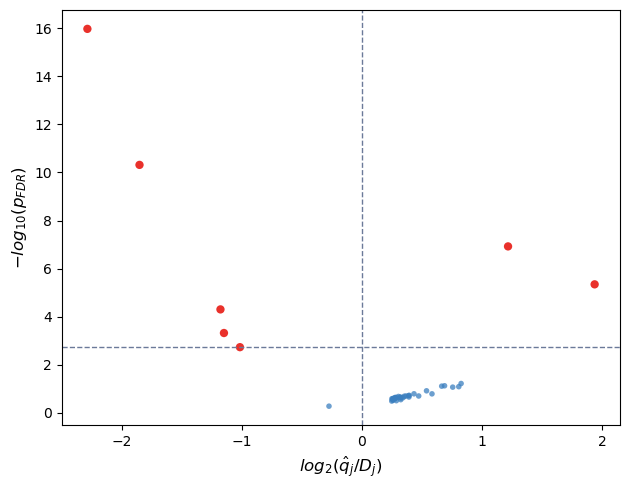


# down_in_recipient features: 6


In [5]:
import importlib, sys
if 'neutrality_test' in sys.modules:
    del sys.modules['neutrality_test']

from neutrality_test import neutrality_lrt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
K, M = 40, 8
features = [f"Feature_{i:02d}" for i in range(K)]
samples  = [f"recipient_{i+1}" for i in range(M)]

donor_counts = rng.integers(50, 800, size=K).astype(float)
p = donor_counts / donor_counts.sum()
p_recip = p.copy()
# deplete the first 6 features, enrich two others -> a spread of fold-changes
p_recip[:6] *= rng.uniform(0.05, 0.3, size=6)
p_recip[6]  *= 3
p_recip[7]  *= 2
p_recip /= p_recip.sum()

recip_cols = {s: rng.multinomial(rng.integers(4000, 6000), p_recip) for s in samples}
recipient_file_layout = pd.DataFrame(recip_cols, index=features)   # rows = features
donor_file_layout     = pd.DataFrame({"donor": donor_counts}, index=features)

# transpose exactly as the app does
donor_series = donor_file_layout.T.iloc[0]
recipient_df = recipient_file_layout.T

results = neutrality_lrt(donor_counts=donor_series, recipient_counts=recipient_df, bottleneck=100.0)
print(results.head(10).to_string(index=False))

# scatter preview
eps = 1e-12
pd:object = results.dropna(subset=["pval","q_hat_recipient_center","p_donor"]).copy()
pdf = results.dropna(subset=["pval","q_hat_recipient_center","p_donor"]).copy()
pdf["log2_fc"]    = np.log2((pdf["q_hat_recipient_center"] + eps) / (pdf["p_donor"] + eps))
pdf["neglog10_p"] = -np.log10(pdf["pval"])
rej = pdf[pdf["reject_FDR"]]
hline = -np.log10(rej["pval"].max()) if len(rej) else -np.log10(0.05)

fig, ax = plt.subplots(figsize=(6.4, 5))
b = pdf[~pdf["reject_FDR"]]; r = pdf[pdf["reject_FDR"]]
ax.scatter(b["log2_fc"], b["neglog10_p"], s=16, c="#3b7fbf", alpha=0.75, edgecolors="none")
ax.scatter(r["log2_fc"], r["neglog10_p"], s=36, c="#e8261f", alpha=0.95, edgecolors="none")
ax.axvline(0.0, ls="--", lw=1, color="#6b7a99")
ax.axhline(hline, ls="--", lw=1, color="#6b7a99")
ax.set_xlabel(r"$log_2(\hat{q}_j / D_j)$", fontsize=12)
ax.set_ylabel(r"$-log_{10}(p_{FDR})$", fontsize=12)
plt.tight_layout(); plt.show()

print("\n# down_in_recipient features:", int((results['direction']=='down_in_recipient').sum()))

## 6 · Launch the Streamlit app

Starts the server locally at **http://localhost:8501**, then tries to open a public URL via `localtunnel`.

> `localtunnel` needs **Node.js** installed. If you see `[WinError 2] The system cannot find the file specified`, Node.js isn't on your PATH — the app still runs locally at the localhost link above. Install Node from https://nodejs.org and re-run, or deploy permanently (see below).

In [6]:
import subprocess, time

proc = subprocess.Popen(
    ["streamlit", "run", "app_neutrality.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)
print("Streamlit started on http://localhost:8501")

try:
    subprocess.run(["npx", "--yes", "localtunnel", "--port", "8501"],
                   check=False, timeout=60)
except Exception as e:
    print(f"localtunnel not available ({e}). Use http://localhost:8501 locally, "
          "or deploy to Streamlit Community Cloud for a permanent public URL.")

Streamlit started on http://localhost:8501
localtunnel not available ([WinError 2] The system cannot find the file specified). Use http://localhost:8501 locally, or deploy to Streamlit Community Cloud for a permanent public URL.


---
### Deploying permanently (no tunnel / Node.js needed)

| Platform | Steps |
|---|---|
| **Streamlit Community Cloud** | Push repo to GitHub -> [share.streamlit.io](https://share.streamlit.io) -> Deploy |
| **Hugging Face Spaces** | Create a Space (Streamlit SDK) -> upload `app_neutrality.py` + `neutrality_test.py` + `requirements.txt` |
| **Render / Railway** | Connect GitHub repo, start command `streamlit run app_neutrality.py --server.port $PORT` |

`requirements.txt` (all six are required on the cloud — matplotlib included):
```
streamlit
numpy
pandas
scipy
statsmodels
matplotlib
```